In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

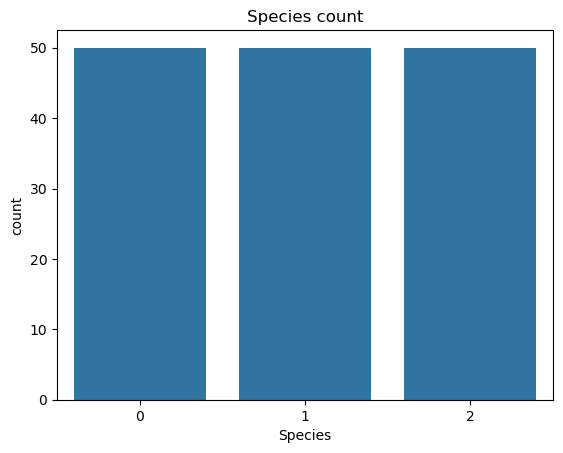

In [9]:
sns.countplot(x = 'Species', data = df)
plt.title('Species count')
plt.show()

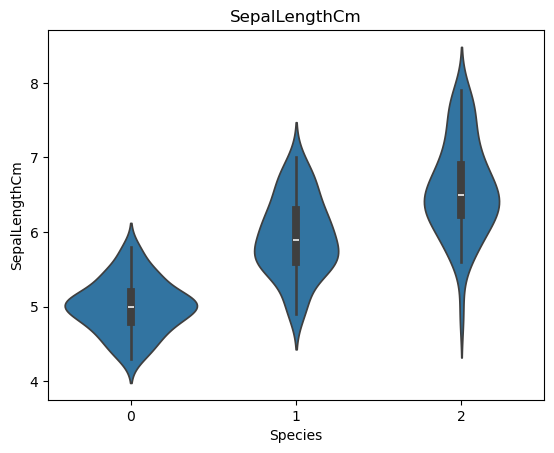

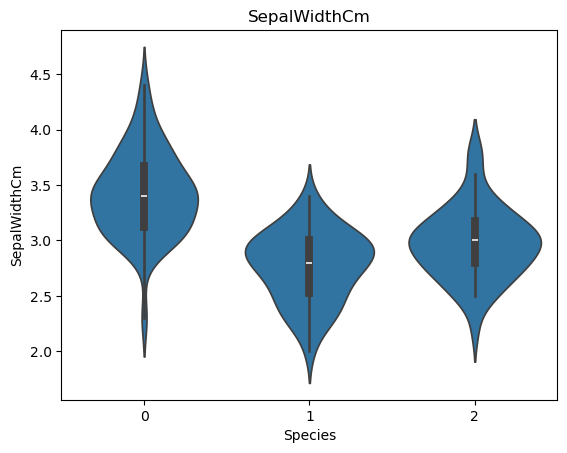

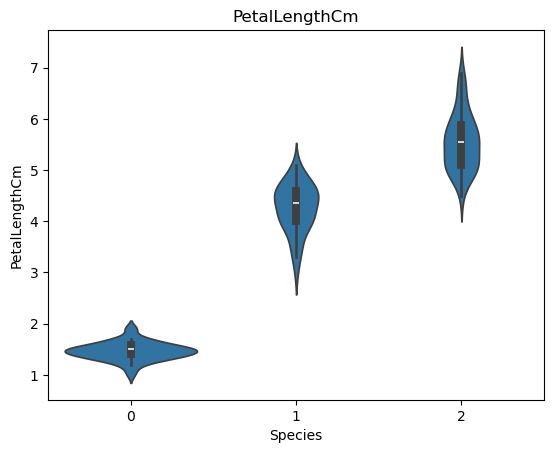

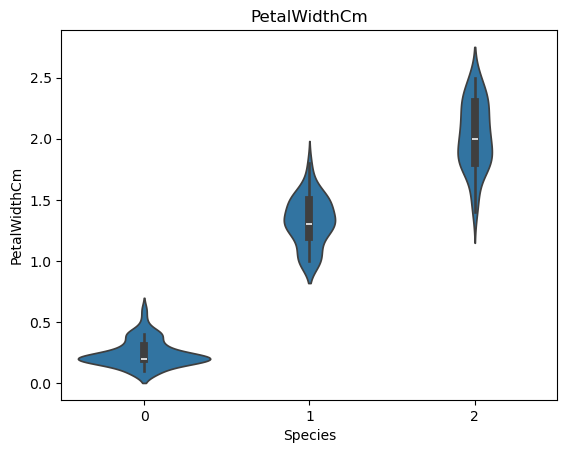

In [13]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
features_names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

for feature in features:
    sns.violinplot(x = 'Species', y = feature, data = df)
    plt.title(feature)
    plt.show()

In [16]:
from sklearn.model_selection import train_test_split
X = df[['SepalLengthCm',	'SepalWidthCm',	'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state= 42)

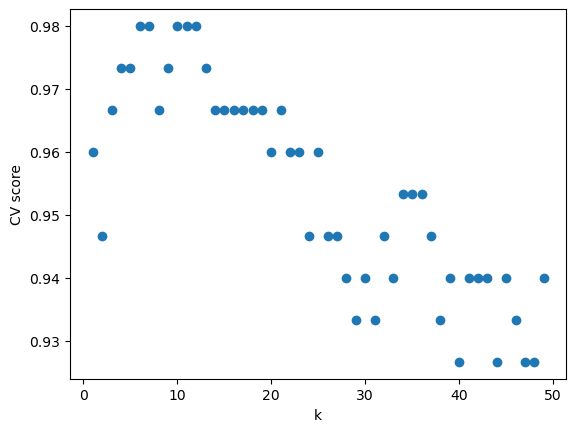

The best k is 6 with 0.9800000000000001 cross validation score


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
k_range = range(1,50)
cv_scores =[]

for k in k_range:
    KNN_model = KNeighborsClassifier(n_neighbors= k)
    scores = cross_val_score(KNN_model, X, y, cv= 5, scoring= 'accuracy')
    cv_scores.append(scores.mean())


plt.plot(k_range, cv_scores, 'o')
plt.xlabel('k')
plt.ylabel('CV score')
plt.show()


best_k = k_range[np.argmax(cv_scores)]
best_cv = cross_val_score(KNeighborsClassifier(n_neighbors= best_k), X, y, cv = 5, scoring = 'accuracy').mean()
print(f'The best k is {best_k} with {best_cv} cross validation score')

In [18]:
best_KNN_model = KNeighborsClassifier(n_neighbors=best_k)
best_KNN_model.fit(X_train, y_train)
y_pred_KNN = best_KNN_model.predict(X_test)

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_KNN))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



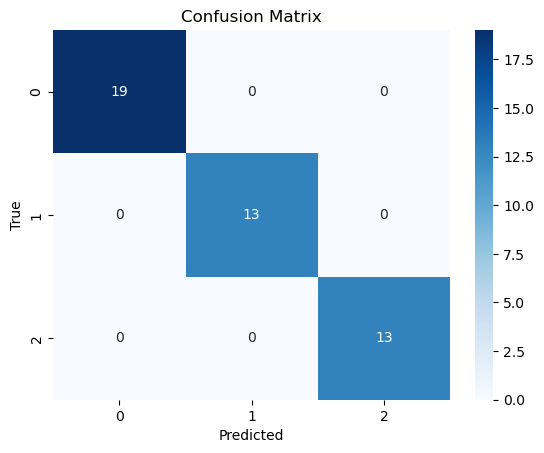

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred_KNN, labels=labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [36]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
accuracy=[]
for kernell in kernels:
    SVC_model = SVC(kernel = kernell)
    SVC_model.fit(X_train_scaled, y_train)
    y_pred_SVC = SVC_model.predict(X_test_scaled)
    score = accuracy_score(y_test, y_pred_SVC)
    accuracy.append(score)

print(accuracy)


[0.9777777777777777, 0.9555555555555556, 1.0, 0.8888888888888888]


In [37]:
i =accuracy.index(max(accuracy))
SVC_model = SVC(kernel = kernels[i])
SVC_model.fit(X_train_scaled, y_train)
y_pred_SVC = SVC_model.predict(X_test_scaled)
print(kernels[i])

rbf


In [38]:
print(np.unique(y_test, return_counts=True))
print(np.unique(y_pred_SVC, return_counts=True))

(array([0, 1, 2]), array([19, 13, 13], dtype=int64))
(array([0, 1, 2]), array([19, 13, 13], dtype=int64))


In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_SVC))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

